# Carga de Datos XRF y Evaluación de Ruido
Este cuaderno carga imágenes TIFF multicanal elementales, evalúa el histograma de intensidad total $T(p)$
y genera la máscara de píxeles válidos.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xrf.io.xrf_loader import Xrf_Loader
from xrf.config import Xrf_Preprocessing_Config

In [9]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data

DATA_DIR = PROJECT_DIR / "data"/ "xrf"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
config = Xrf_Preprocessing_Config(Noise_Threshold=5.0)

In [11]:
file_paths = [
    RAW_DATA_DIR / "page_001_Ca.tiff",
    RAW_DATA_DIR / "page_001_Fe.tiff",
    RAW_DATA_DIR / "page_001_Cu.tiff",
    RAW_DATA_DIR / "page_001_Pb.tiff",
]

# Crear datos sintéticos si los archivos reales no existen en el entorno de desarrollo
if not file_paths[0].exists():
    print("Archivos no encontrados, generando cubo de datos sintético (100x100x4)...")
    stack = np.random.rand(100, 100, 4) * 10
else:
    stack = Xrf_Loader.Load_Element_Stack(file_paths, Dtype=config.Compute_Dtype)

print(f"Dimensiones del cubo original: {stack.shape}")

Archivos no encontrados, generando cubo de datos sintético (100x100x4)...
Dimensiones del cubo original: (100, 100, 4)


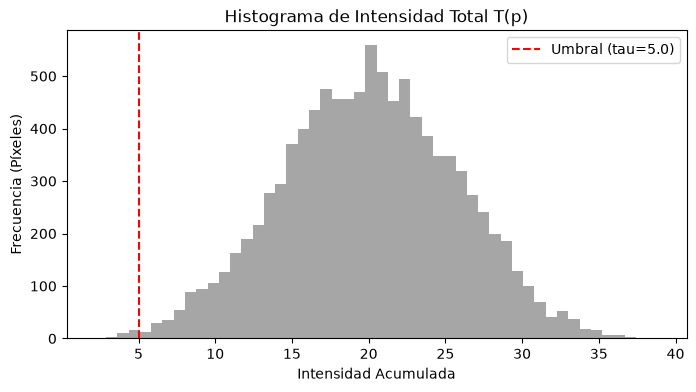

Píxeles válidos retenidos: 9973 (99.7%)


In [12]:
# Calcular Intensidad Total T(p) y generar máscara
total_intensity = np.sum(stack, axis=-1)

plt.figure(figsize=(8, 4))
plt.hist(total_intensity.ravel(), bins=50, color="gray", alpha=0.7)
plt.axvline(
    x=config.Noise_Threshold,
    color="red",
    linestyle="--",
    label=f"Umbral (tau={config.Noise_Threshold})",
)
plt.title("Histograma de Intensidad Total T(p)")
plt.xlabel("Intensidad Acumulada")
plt.ylabel("Frecuencia (Píxeles)")
plt.legend()
plt.show()

mask, valid_pixels = Xrf_Loader.Compute_Intensity_Mask(stack, config.Noise_Threshold)
print(
    f"Píxeles válidos retenidos: {valid_pixels.shape[0]} ({valid_pixels.shape[0] / total_intensity.size:.1%})"
)

In [13]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

np.save(PROCESSED_DATA_DIR / "page_001_mask.npy", mask)
np.save(PROCESSED_DATA_DIR / "page_001_valid_pixels.npy", valid_pixels)

print(f"Datos exportados a {PROCESSED_DATA_DIR}")

Datos exportados a c:\Users\gabri\Documento\Mitacs\research_ct\data\xrf\output\processed
